# Tutorial 5 - FOSWEC
This tutorial models the floating oscillating surge wave energy converter (FOSWEC) and examines adding top-mounted ballast to the FOSWEC flaps. 
The FOSWEC has been tested in [multiple experimental campaigns at the Oregon State University (OSU) O.H. Hinsdale Wave Research Laboratory (HWRL) Directional Wave Basin (DWB)](https://mhkdr.openei.org/submissions/350) and a [WEC-Sim numerical model](https://github.com/WEC-Sim/FOSWEC2) has been previously developed and validated against experimental data.

The FOSWEC is a coupled multibody system consisting of two flaps pitching relative to a floating platform. 
Efficiently modeling this system in WecOptTool requires a reduced-coordinate formulation. 
In this tutorial, that reduction is performed using [Multibody for Everybody](https://github.com/Project-SEA-Stack/Python_Multibody_for_Everybody) (M4E), a package developed by the National Laboratory of the Rockies (NLR).

![FOSWEC image](https://live.staticflickr.com/65535/55515103812_77d48575c1_z.jpg)

While previous WecOptTool tutorials focus on a single degree of freedom (DOF) or a small set of coupled DOFs, many WEC archetypes have more complex and coupled dynamics that would otherwise require manually defining kinematic constraints or reduced-coordinate equations of motion. 
M4E automates this process by transforming the hydrodynamic, hydrostatic, kinematic, and external force terms from global to joint coordinates.
For the FOSWEC, this reduces the planar model from 9 global coordinates to 5 joint coordinates, preserving important platform-flap coupling while reducing the number of optimization state variables significantly.
M4E eliminates the need for manually deriving reduced-coordinate equations, which can be time-consuming and error prone, and greatly improves the computational efficiency, since the WecOptTool optimization cost roughly scales with the square of the number of optimization variables.

Using Multibody for Everybody with WecOptTool requires the following main steps:
1. Create an [M4E input file](M4E_inputs/FOSWEC_M4E_inputs.py). This defines the body properties, joint locations, and joint types and needs to be imported into the current notebook.
2. After running BEM for all rigid body degrees of freedom, call `wot.utilities.setup_from_M4E()` to assemble the reduced impedance matrix, reduced excitation coefficients, and coordinate transformation matrix.
3. Convert PTO kinematics and external force matrices to reduced coordinates using `wot.utilities.reduce_PTO_kinematics_M4E()` and `wot.utilities.reduce_damping_stiffness_M4E()`.
4. Set up the WEC object using the `from_impedance` method and solve the optimization problem. 

This tutorial consists of three parts. 
First, the model is set up and converted to reduced coordinates using M4E.
Next, the unoptimized response is compared to an equivalent WEC-Sim model for code-to-code verification. 
Then, the impact of adding top-mounted ballast to the flaps is analyzed.

1. [Model setup](#1.-Model-setup)
2. [Model verification](#2.-Model-verification)
3. [Top-mounted ballast study](#3.-Top-mounted-ballast-study)

In [1]:
import capytaine as cpy
from capytaine.io.meshio import load_from_meshio
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import xarray as xr
import gmsh, pygmsh

import wecopttool as wot

## set colorblind-friendly colormap for plots
plt.style.use('tableau-colorblind10')

## 1. Model setup

### 1.1 Wave Conditions
For the initial code-to-code verification, three difference regular wave amplitudes are tested.
The first wave has a very small amplitude to ensure the response remains within the linear range of operation. 
The intermediate wave amplitude matches a condition previously tested in the wave tank, while the largest wave height is included to further evaluate the effect of larger-amplitude motion on the linearized M4E formulation. 

Since we are using only regular waves and linear proportional control gains in this tutorial, the system is entirely linear.
Thus, only 2 frequencies are needed, enabling a computationally efficient optimization.
For irregular waves or any control introducing nonlinearities (e.g., unstructured), additional frequencies would be necessary to properly model the dynamics.

In [2]:
# Frequency object
wavefreq    = 1/2.61 # Hz
f1          = wavefreq
nfreq       = 2
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

# Define wave cases
wave_heights = [0.001, 0.136, 0.272]  # m
wave_amplitudes = [height / 2 for height in wave_heights]
phase = 0    # degrees
wavedir = 0  # degrees
waves = [
    wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)
    for amplitude in wave_amplitudes
]

### 1.2 WEC Geometry

The FOSWEC consists of two flaps pitching relative to a floating platform. 
The geometry is defined below including each of the three meshes, their hydrostatic properties, and the degrees of freedom (DOFs) for solving the boundary element method (BEM) problem.

Usually, only the relevant DOFs are defined for each floating body in Capytaine.
However, since M4E is handling the transformation from global to reduced coordinates, we add all 6 rigid body DOFs defined about the center of gravity using Capytaine.

In [3]:
# flap dimensions and properties
flap_thickness_bottom = 0.04
flap_thickness_top = 0.1
flap_center_distance_apart = 1.44  # distance between two flap centers in the direction of wave propagation
flap_width = 0.76
flap_height = 0.58
flap_draft = 0.59  # Fully submerged
cg_height_above_hinge = 0.17
flap1_cg = [-flap_center_distance_apart / 2, 0, -flap_draft + cg_height_above_hinge]  # from water surface/origin
flap2_cg = [flap_center_distance_apart / 2, 0, -flap_draft + cg_height_above_hinge]  # from water surface/origin
flap_mass = 23.1
flap_inertia = 1.19

# platform dimensions and properties; consists of a frame, a DAQ box, and four columns
platform_frame_length = 1.44
platform_frame_thickness = 0.05
platform_frame_width = 1.06
platform_frame_top_depth = 0.53 + 0.1
platform_cg = [0, 0, -0.8]
platform_mass = 189.8
platform_inertia = 30
cutout_width = platform_frame_width - 2 * platform_frame_thickness
cutout_length = platform_frame_length - 2 * platform_frame_thickness

full_width = 1.63
columns_radius = 0.1
columns_draft = 0.53 + 0.1 + 0.4
columns_xy = [flap_center_distance_apart / 2, full_width / 2 - columns_radius]

daq_length = 0.72
daq_width = 0.6
daq_height = 0.2
daq_top_depth = 0.53 + 0.1 + 0.05

# Define the meshes
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber("Mesh.MeshSizeFactor", 0.3)
    platform = geom.add_box(
        [-platform_frame_length / 2, -platform_frame_width / 2, -platform_frame_top_depth - platform_frame_thickness],
        [platform_frame_length, platform_frame_width, platform_frame_thickness],
    )
    cutout = geom.add_box(
        [-cutout_length / 2, -cutout_width / 2, -platform_frame_top_depth - platform_frame_thickness],
        [cutout_length, cutout_width, platform_frame_thickness],
    )
    cyl1 = geom.add_cylinder(
        [-columns_xy[0], -columns_xy[1], -columns_draft],
        [0, 0, columns_draft + 0.01],
        columns_radius,
    )
    cyl2 = geom.add_cylinder(
        [-columns_xy[0], columns_xy[1], -columns_draft],
        [0, 0, columns_draft + 0.01],
        columns_radius,
    )
    cyl3 = geom.add_cylinder(
        [columns_xy[0], -columns_xy[1], -columns_draft],
        [0, 0, columns_draft + 0.01],
        columns_radius,
    )
    cyl4 = geom.add_cylinder(
        [columns_xy[0], columns_xy[1], -columns_draft],
        [0, 0, columns_draft + 0.01],
        columns_radius,
    )
    daq = geom.add_box(
        [-daq_length / 2, -daq_width / 2, -daq_top_depth - daq_height],
        [daq_length, daq_width, daq_height],
    )
    platform_frame = geom.boolean_difference(platform, cutout)
    geom.boolean_union([platform_frame, daq, cyl1, cyl2, cyl3, cyl4])
    platform_mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
        [
            [-flap_center_distance_apart / 2 - flap_thickness_bottom / 2, -flap_width / 2, -flap_draft],
            [-flap_center_distance_apart / 2 + flap_thickness_bottom / 2, -flap_width / 2, -flap_draft],
            [-flap_center_distance_apart / 2 + flap_thickness_top / 2, -flap_width / 2, flap_height - flap_draft],
            [-flap_center_distance_apart / 2 - flap_thickness_top / 2, -flap_width / 2, flap_height - flap_draft],
        ],
        mesh_size=0.1,
    )
    geom.extrude(flap1, [0, flap_width, 0])
    flap1_mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
        [
            [flap_center_distance_apart / 2 - flap_thickness_bottom / 2, -flap_width / 2, -flap_draft],
            [flap_center_distance_apart / 2 + flap_thickness_bottom / 2, -flap_width / 2, -flap_draft],
            [flap_center_distance_apart / 2 + flap_thickness_top / 2, -flap_width / 2, flap_height - flap_draft],
            [flap_center_distance_apart / 2 - flap_thickness_top / 2, -flap_width / 2, flap_height - flap_draft],
        ],
        mesh_size=0.1,
    )
    geom.extrude(flap2, [0, flap_width, 0])
    flap2_mesh = geom.generate_mesh()

# define functions for creating inertia matrix and floating body
def make_inertia_matrix(body, mass, inertia):
    return xr.DataArray(
        data=np.diag([mass, mass, mass, inertia, inertia, inertia]),
        dims=["influenced_dof", "radiating_dof"],
        coords={
            "influenced_dof": list(body.dofs),
            "radiating_dof": list(body.dofs),
        },
        name="inertia_matrix",
    )

def make_floating_body(mesh, name, center_of_mass, mass, inertia):
    body = cpy.FloatingBody(mesh=mesh, name=name, center_of_mass=center_of_mass)
    body.add_all_rigid_body_dofs()
    body.rotation_center = body.center_of_mass
    body.inertia_matrix = make_inertia_matrix(body, mass, inertia)
    body.hydrostatic_stiffness = body.immersed_part().compute_hydrostatic_stiffness()
    return body

# Create floating bodies for platform and flaps and combine
platform = make_floating_body(platform_mesh, "platform", platform_cg, platform_mass, platform_inertia)
flap1 = make_floating_body(flap1_mesh, "flap1", flap1_cg, flap_mass, flap_inertia)
flap2 = make_floating_body(flap2_mesh, "flap2", flap2_cg, flap_mass, flap_inertia)

foswec_fb = platform + flap1 + flap2

### 1.3 Hydrodynamics

Next, we run the BEM using [Capytaine](https://github.com/capytaine/capytaine) to obtain the hydrodynamic coefficients for the FOSWEC.
Capytaine returns the hydrodynamic matrices and coefficients for the full 18 rigid body DOFs.

In [4]:
# run BEM calculations
bem_data = wot.run_bem(foswec_fb, freq, depth=2)

[22:48:58] WARNING  Using the geometric centroid as the center of gravity (COG).

           WARNING  Using the center of gravity (COG) as the rotation center for hydrostatics. Note that the       
                    hydrostatics do not use the axes defined by the FloatingBody degrees of freedom, and the       
                    rotation center should be set manually when using Capytaine to calculate hydrostatics about an 
                    axis other than the COG.

Output()

### 1.4 Multibody for Everybody

After generating BEM coefficients for all rigid body DOFs, Multibody for Everybody is called to reduce from global coordinates to joint coordinates.
M4E is only set up for planar DOFs, so it ignores the sway, roll, and yaw coefficients for each body and reduces the remaining coefficients (surge, heave, and pitch) to joint coordinates.
Thus, the FOSWEC is reduced from 9 global planar coordinates to 5 joint coordinates.
`wot.utilities.setup_from_M4E()` calls M4E, inputting the M4E input file, BEM coefficients, floating bodies, and mass proerties, and sets up the reduced-coordinate impedance matrix, excitation coefficients, and hydrostatic stiffness matrix to be used in setting up the WEC object. 
The utilities function also returns `R0`, which is the transformation matrix used for coordinate conversion, and the number of M4E DOFs per body, `M4E_ndof`.

In [5]:
from M4E_inputs import FOSWEC_M4E_inputs

# create multibody system for wavebot using M4E
m0 = [platform_mass, flap_mass, flap_mass]
J0 = [platform_inertia, flap_inertia, flap_inertia]

# return the reduced coordinate matrices
impedance_reduced, excitation_reduced, hydrostatic_stiffness_reduced, R0, M4E_ndof = wot.utilities.setup_from_M4E(FOSWEC_M4E_inputs, bem_data, [platform, flap1, flap2], m0, J0)

Problem initialization finished in:		 0.001 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.072 seconds
Symbolic EOM computation finished in:		 0.034 seconds


Compiling EOM expressions finished in:		 0.115 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .




[HydroAdapter] Prepared bodies:
  [1] name='platform', CoM=[ 0.   0.  -0.8]
  [2] name='flap1', CoM=[-0.72  0.   -0.42]
  [3] name='flap2', CoM=[ 0.72  0.   -0.42]


### 1.5 Additional forces

Additional forces acting on the FOSWEC include the mooring stiffness and damping on the platform and linear damping on the flaps.
The damping and stiffness matrices are defined in the global planar DOFs and transformed to reduced coordinates using `wot.utilities.reduce_damping_stiffness_M4E()` and the coordinate transformation matrix, `R0`.
Then, the force functions are defined normally using the reduced-coordinate matrices.
For the code-to-code verification, no PTO is included here.

In [6]:
# set mooring stiffness and damping matrices and reduce to joint coordinates
mooring_stiffness_full = np.diag([8e3, 2e5, 2e5, 0, 0, 0, 0, 0, 0])
mooring_stiffness = wot.utilities.reduce_damping_stiffness_M4E(mooring_stiffness_full, R0)

mooring_damping_full = np.diag([8e2, 1e4, 1e4, 0, 0, 0, 0, 0, 0])
mooring_damping = wot.utilities.reduce_damping_stiffness_M4E(mooring_damping_full, R0)

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    mooring_force = jnp.dot(time_matrix,mooring)
    return mooring_force

# set linear damping matrix (flap linear damping) and reduce to joint coordinates
flap_linear_damping_full = np.diag([0, 0, 0, 0, 0, 10, 0, 0, 10])
flap_linear_damping = wot.utilities.reduce_damping_stiffness_M4E(flap_linear_damping_full, R0)

def f_linear_damping(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)
    damping = - vel @ flap_linear_damping
    linear_damping_force = jnp.dot(time_matrix, damping)
    return linear_damping_force

# define added forces
f_add = {'f_mooring': f_mooring, 'f_linear_damping': f_linear_damping} 

### 1.6 WEC object

The WEC object is defined using the `from_impedance` method with the reduced-coordinate matrices and coefficients.

In [7]:
# Define the WEC object using the from_impedance method
wec = wot.WEC.from_impedance(
    waves[0].freq.values,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=hydrostatic_stiffness_reduced,
    constraints=None,
    f_add=f_add,
)

### 1.7 Objective function

For the code-to-code verification, we are not applying any PTO/control forces. 
The objective function is therefore set to zero with no optimization variables.

In [8]:
# Objective function - none for now
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

## 2. Model verification

### 2.1 Solve

With the objective function set to zero, WecOptTool solves for a feasible periodic response by enforcing the dynamic residual constraint, effectively solving the multibody dynamics problem.
The problem is solved for each verification wave condition.
For post-processing, `wot.utilities.post_process_M4E()` formats the results and converts them back to the global planar coordinates.

In [9]:
# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results_all = []
wec_fdom_full_all = []
wec_tdom_full_all = []

nsubsteps = 10

for wave in waves:
    # Solve
    results = wec.solve(
        wave,
        obj_fun,
        nstate_opt,
        scale_x_wec=scale_x_wec,
        scale_x_opt=scale_x_opt,
        scale_obj=scale_obj,
    )

    # Post-process results
    wec_fdom_full, wec_tdom_full = wot.utilities.post_process_M4E(
        wec, results, wave, nsubsteps, R0
    )

    # Store outputs
    results_all.append(results)
    wec_fdom_full_all.append(wec_fdom_full)
    wec_tdom_full_all.append(wec_tdom_full)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


### 2.2 Code-to-code comparison

To verify the WecOptTool+M4E model, the results are compared to an equivalent WEC-Sim model.
The small waves ensure the system remains entirely within the linear range of operation since M4E linearizes the dynamics while WEC-Sim models the nonlinear dynamics.
Within the small wave conditions, a near perfect match is achieved between the WecOptTool+M4E and WEC-Sim models. 
As the wave height is increased, the difference between the WecOptTool and WEC-Sim results increases. 
Still, the relatively low error across the tested wave conditions verifies the WecOptTool+M4E model and supporting its use in co-design and optimization studies.

/tmp/ipykernel_4514/252279905.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


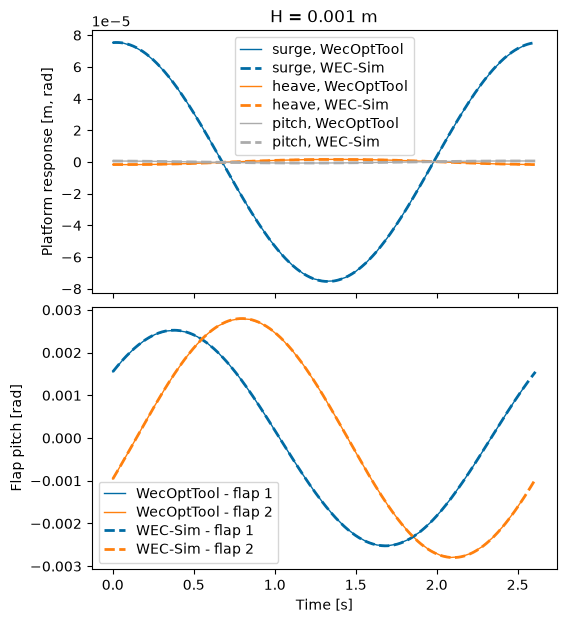

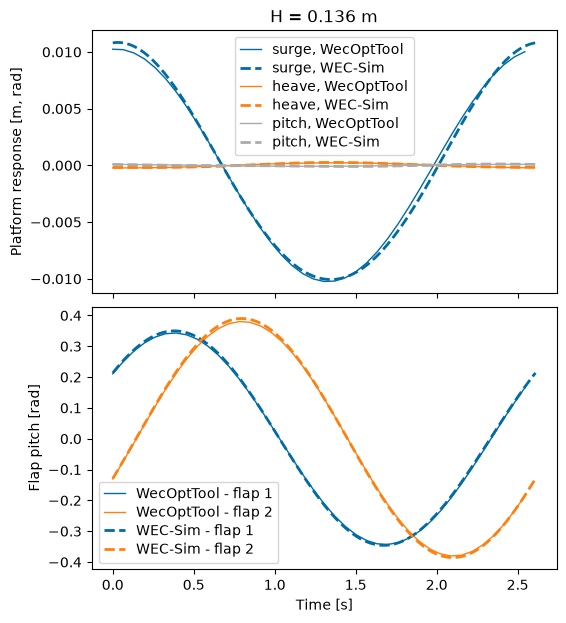

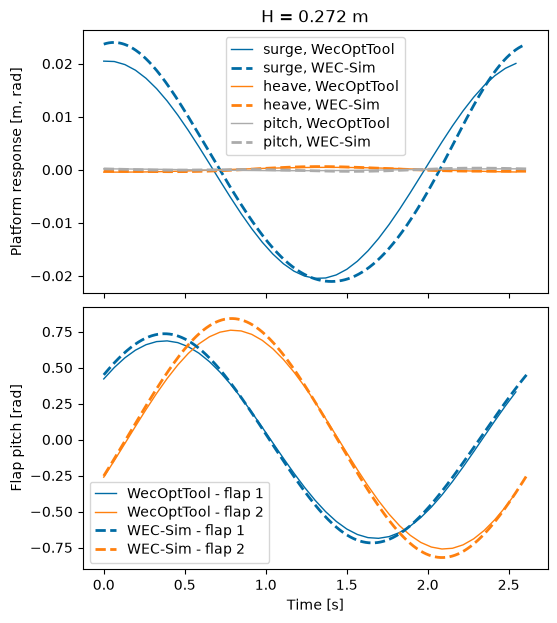

In [10]:
# Load combined WEC-Sim results
ws_data = xr.open_dataset("data/FOSWEC_WS_data.nc")

for i in range(ws_data.sizes["case"]):
    ws_output = ws_data.isel(case=i)
    wave_height = ws_output.wave_height.values
    wec_tdom_full = wec_tdom_full_all[i]

    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6, 7),gridspec_kw={"hspace": 0.05})

    ws_time_period = ws_output.time
    wec_time_period = wec_tdom_full["time"]

    # Platform response
    axs[0].plot(wec_time_period,wec_tdom_full.sel(realization=0).pos[0, :],"C0-",linewidth=1,label="surge, WecOptTool",)
    axs[0].plot(ws_time_period,ws_output.platform_response[:, 0],"C0--",linewidth=2,label="surge, WEC-Sim",)
    axs[0].plot(wec_time_period,wec_tdom_full.sel(realization=0).pos[1, :],"C1-",linewidth=1,label="heave, WecOptTool",)
    axs[0].plot(ws_time_period,ws_output.platform_response[:, 2] - platform_cg[2],"C1--",linewidth=2,label="heave, WEC-Sim",)
    axs[0].plot(wec_time_period,wec_tdom_full.sel(realization=0).pos[2, :],"C2-",linewidth=1,label="pitch, WecOptTool",)
    axs[0].plot(ws_time_period,ws_output.platform_response[:, 4],"C2--",linewidth=2,label="pitch, WEC-Sim",)
    axs[0].set_ylabel("Platform response [m, rad]")
    axs[0].set_title(f"H = {wave_height:.3f} m")
    axs[0].legend(fontsize=10, handlelength=1.5, labelspacing=0.3)

    # Flap response
    axs[1].plot(wec_time_period,wec_tdom_full.sel(realization=0).pos[5, :],color="C0",linewidth=1,label="WecOptTool - flap 1",)
    axs[1].plot(wec_time_period,wec_tdom_full.sel(realization=0).pos[8, :],color="C1",linewidth=1,label="WecOptTool - flap 2",)
    axs[1].plot(ws_time_period,ws_output.pto1_response[:, 4],"--",color="C0",linewidth=2,label="WEC-Sim - flap 1",)
    axs[1].plot(ws_time_period,ws_output.pto2_response[:, 4],"--",color="C1",linewidth=2,label="WEC-Sim - flap 2",)
    axs[1].set_xlabel("Time [s]")
    axs[1].set_ylabel("Flap pitch [rad]")
    axs[1].legend(fontsize=10, handlelength=1.5, labelspacing=0.3)

    plt.tight_layout()

## 3. Top-mounted ballast study

### 3.1 Top-mounted ballast impact on hydrostatic stiffness

Adding ballast to the top of the flaps moves their center of gravity upward (increase center of gravity height).
As shown below, this reduces the distance between the center of gravity and center of buoyancy, creating a destabilizing effect that reduces the hydrostatic stiffness.
The reduced hydrostatic stiffness may increase the WEC response and improve power capture, particularly if the flap rotation constraints are not already active.

<img src="https://live.staticflickr.com/65535/55516113281_91853bfbd1_b.jpg" alt="flap_cg_gs" width="400">

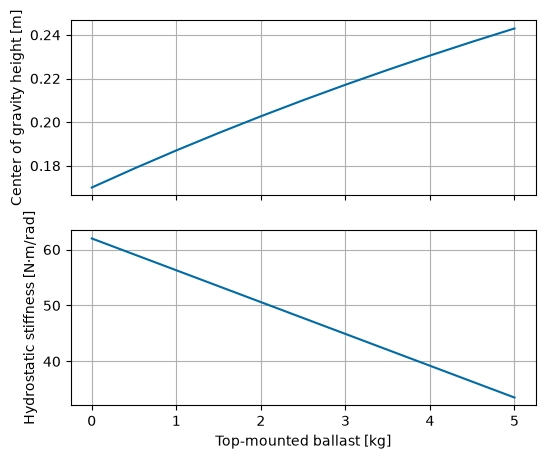

In [11]:
# plot mass on top effects
top_mounted_ballast_vec = np.linspace(0, 5, 11)

# Define mesh for single centered flap
with pygmsh.geo.Geometry() as geom:
    flap = geom.add_polygon(
        [[-flap_thickness_bottom / 2, -flap_width / 2, -flap_draft],
        [flap_thickness_bottom / 2, -flap_width / 2, -flap_draft],
        [flap_thickness_top / 2, -flap_width / 2, flap_height - flap_draft],
        [-flap_thickness_top / 2, -flap_width / 2, flap_height - flap_draft],],mesh_size=0.1,)
    geom.extrude(flap, [0, flap_width, 0])
    flap_mesh = geom.generate_mesh()

# determine new center of gravity height and hydrostatic stiffness for different top-mounted ballast values
cg_height_vec = []
hydrostatic_stiffness_vec = []
for top_mounted_ballast in top_mounted_ballast_vec:
    # Define FloatingBody
    cg_height_above_hinge_new = (cg_height_above_hinge*flap_mass + top_mounted_ballast*flap_height)/(flap_mass + top_mounted_ballast)
    flap_cg = [0, 0, -flap_draft + cg_height_above_hinge_new]
    flap = cpy.FloatingBody(mesh=flap_mesh, name="flap", center_of_mass=flap_cg)

    # Define rotation dof
    flap.rotation_center = (0, 0, -flap_draft)
    flap.add_rotation_dof(name='Pitch')

    # Set FloatingBody inertia matrix
    flap.mass = flap_mass + top_mounted_ballast
    flap_inertia_hinge = flap_inertia + (flap_mass + top_mounted_ballast)*cg_height_above_hinge_new**2
    rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([flap_inertia_hinge]))),
                                dims=['influenced_dof', 'radiating_dof'],
                                coords={'influenced_dof': list(flap.dofs),
                                        'radiating_dof': list(flap.dofs)},
                                name="inertia_matrix")
    flap.inertia_matrix = rigid_inertia_matrix_xr

    # record cg height and hydrostatic stiffness
    flap.hydrostatic_stiffness = flap.immersed_part().compute_hydrostatic_stiffness()
    cg_height_vec.append(cg_height_above_hinge_new)
    hydrostatic_stiffness_vec.append(flap.hydrostatic_stiffness)

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6, 5))

axs[0].plot(top_mounted_ballast_vec, cg_height_vec)
axs[0].set_ylabel("Center of gravity height [m]")
axs[0].grid(True)

axs[1].plot(top_mounted_ballast_vec, np.squeeze(hydrostatic_stiffness_vec))
axs[1].set_xlabel("Top-mounted ballast [kg]")
axs[1].set_ylabel("Hydrostatic stiffness [N·m/rad]")
axs[1].grid(True)


### 3.2 Top-mounted ballast study loop

The top-mounted ballast study loops through ballast mass, wave period, and wave amplitude.
Capytaine is rerun for each ballast mass and wave period to generate the hydrodynamic coefficients using the updated mass properties and required frequencies.
The PTO, additional forces, and constraints are defined for each case, and the optimization is run to determine the optimal controller gains and added stiffness coefficients.

Sometimes the optimization converges to local optima. To reduce sensitivity to the initial guess, each case is optimized multiple times using different initial conditions, and the solution with the highest generated power is selected.

*Note that a few details differ from the corresponding paper, including the case discretization and controller formulation: this tutorial uses a proportional controller, while the paper uses an unstructured controller.*

#### 3.2.1 PTO

Since no PTO was included in the verification setup, the PTO dynamics, kinematics, and constraints are now included here.
Although there are two PTO units in reality, they can be represented together by one kinematics matrix and one impedance matrix.
The PTOs are connected between the flap and the platform and resist the relative pitch motion between them. 

The PTO kinematics matrix maps the global planar coordinates to the two PTO coordinates: flap 1 pitch relative to the platform and flap 2 pitch relative to the platform. 
This kinematics matrix is reduced to joint coordinates using `wot.utilities.reduce_PTO_kinematics_M4E()`.

The PTO dynamics are defined using the two-port impedance model based on the drivetrain and generator parameters.
Because there are two PTOs, the combined PTO impedance matrix is 4x4: two mechanical ports and two electrical ports.
In this formulation, rows/columns 1 and 3 correspond to the mechanical and electrical ports of the first PTO, while rows/columns 2 and 4 correspond to the mechanical and electrical ports of the second PTO.

#### 3.2.2 Optimal drivetrain stiffness

Along with optimizing the PTO controller gains, an optimized stiffness coefficient is added to each flap to represent an added torsional spring. 
The added stiffness coefficients give the optimizer an additional design variable that can compensate for changes in hydrostatic stiffness while still satisfying the maximum flap rotation constraints.

#### 3.2.3 Controller

A proportional controller is used here for efficient optimization, providing linear damping control. There are two proportional gains: one for each PTO. 

#### 3.2.4 Constraints

The constraints include rotational constraints for each flap and peak and rms generator torque limits.


In [12]:
top_mounted_ballast_vec = np.linspace(0, 2, 3)
wave_periods = [1, 3, 6]
wave_amplitudes = [0.05, 0.15, 0.25]

case_outputs = []

for top_mounted_ballast in top_mounted_ballast_vec:

    # redefine floating bodies with top-mounted ballast
    platform = make_floating_body(platform_mesh, "platform", platform_cg, platform_mass, platform_inertia)
    total_flap_mass = flap_mass + top_mounted_ballast
    cg_height_above_hinge_new = (flap_mass * cg_height_above_hinge + top_mounted_ballast * flap_height) / total_flap_mass
    flap_inertia_new = flap_inertia + (flap_mass*top_mounted_ballast/total_flap_mass)*(flap_height - cg_height_above_hinge)**2
    flap1_cg = [-flap_center_distance_apart / 2, 0, -flap_draft + cg_height_above_hinge_new]
    flap1 = make_floating_body(flap1_mesh, "flap1", flap1_cg, total_flap_mass, flap_inertia_new)
    flap2_cg = [flap_center_distance_apart / 2, 0, -flap_draft + cg_height_above_hinge_new]
    flap2 = make_floating_body(flap2_mesh, "flap2", flap2_cg, total_flap_mass, flap_inertia_new)
    foswec_fb = platform + flap1 + flap2
    
    for wave_period in wave_periods:

        # define frequency object
        wavefreq    = 1/wave_period # Hz
        f1          = wavefreq
        nfreq       = 2
        freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

        # run BEM calculations for wave period
        bem_data = wot.run_bem(foswec_fb, freq, depth=2)

        # create multibody system for wavebot using M4E
        m0 = [platform_mass, total_flap_mass, total_flap_mass]
        J0 = [platform_inertia, flap_inertia_new, flap_inertia_new]

        # return the reduced coordinate matrices
        impedance_reduced, excitation_reduced, hydrostatic_stiffness_reduced, R0, M4E_ndof = wot.utilities.setup_from_M4E(FOSWEC_M4E_inputs, bem_data, [platform, flap1, flap2], m0, J0)

        for wave_amplitude in wave_amplitudes:

            # define wave case
            amplitude = wave_amplitude
            phase = 0    # degrees
            wavedir = 0  # degrees
            waves = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

            ## PTO impedance definition
            omega = bem_data.omega.values
            gear_ratio = 3.75
            torque_constant = 1.021
            winding_resistance = 1.028
            winding_inductance = 0.0
            drivetrain_inertia = 0.05
            drivetrain_friction_aft = 3.27 / 3.75**2
            drivetrain_friction_bow = 2.7 / 3.75**2
            drivetrain_stiffness = 0.0

            drivetrain_impedance_aft = (
                1j * omega * drivetrain_inertia
                + drivetrain_friction_aft
                + 1 / (1j * omega) * drivetrain_stiffness
            )
            drivetrain_impedance_bow = (
                1j * omega * drivetrain_inertia
                + drivetrain_friction_bow
                + 1 / (1j * omega) * drivetrain_stiffness
            )

            winding_impedance = winding_resistance + 1j * omega * winding_inductance

            pto_impedance_11_aft = -1 * gear_ratio**2 * drivetrain_impedance_aft
            pto_impedance_11_bow = -1 * gear_ratio**2 * drivetrain_impedance_bow
            off_diag = np.sqrt(3.0 / 2.0) * torque_constant * gear_ratio
            pto_impedance_12 = -1 * (off_diag + 0j) * np.ones(omega.shape)
            pto_impedance_21 = -1 * (off_diag + 0j) * np.ones(omega.shape)
            pto_impedance_22 = winding_impedance

            pto_impedance = np.zeros((4, 4, len(omega)), dtype=complex)
            pto_impedance[0, 0, :] = pto_impedance_11_aft
            pto_impedance[1, 1, :] = pto_impedance_11_bow
            pto_impedance[0, 2, :] = pto_impedance_12
            pto_impedance[1, 3, :] = pto_impedance_12
            pto_impedance[2, 0, :] = pto_impedance_21
            pto_impedance[3, 1, :] = pto_impedance_21
            pto_impedance[2, 2, :] = pto_impedance_22
            pto_impedance[3, 3, :] = pto_impedance_22

            # PTO settings
            pto_ndof = 2
            controller = wot.controllers.pid_controller(ndof_pto=pto_ndof, proportional=True, integral=False, derivative=False)
            loss = None
            names = ["flap 1 PTO","flap 2 PTO"]

            # PTO kinematics
            pto_kinematics_full = np.array(
                [[0, 0, -1, 0, 0, 1, 0, 0, 0],
                [0, 0, -1, 0, 0, 0, 0, 0, 1],]
            )
            pto_kinematics_reduced = wot.utilities.reduce_PTO_kinematics_M4E(pto_kinematics_full, R0)

            pto = wot.pto.PTO(pto_ndof, pto_kinematics_reduced, controller, pto_impedance, loss, names)

            mooring_stiffness = wot.utilities.reduce_damping_stiffness_M4E(mooring_stiffness_full, R0)
            mooring_damping = wot.utilities.reduce_damping_stiffness_M4E(mooring_damping_full, R0)
            flap_linear_damping = wot.utilities.reduce_damping_stiffness_M4E(flap_linear_damping_full, R0)

            def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
                pos = wec.vec_to_dofmat(x_wec)
                vel = jnp.dot(wec.derivative_mat, pos)
                time_matrix = wec.time_mat_nsubsteps(nsubsteps)
                force = -pos @ mooring_stiffness - vel @ mooring_damping
                return jnp.dot(time_matrix, force)
            def f_linear_damping(wec, x_wec, x_opt, wave, nsubsteps=1):
                pos = wec.vec_to_dofmat(x_wec)
                vel = jnp.dot(wec.derivative_mat, pos)
                time_matrix = wec.time_mat_nsubsteps(nsubsteps)
                force = -vel @ flap_linear_damping
                return jnp.dot(time_matrix, force)
            def f_drivetrain_stiffness_flap1(wec, x_wec, x_opt, wave, nsubsteps=1):
                pto_pos = pto.position(wec, x_wec, x_opt, wave, nsubsteps)
                flap1_stiffness = x_opt[-2]
                spring_force_pto = jnp.zeros_like(pto_pos)
                spring_force_pto = spring_force_pto.at[:, 0].set(-flap1_stiffness * pto_pos[:, 0])
                spring_force_wec = jnp.dot(spring_force_pto, pto_kinematics_reduced)
                return spring_force_wec
            def f_drivetrain_stiffness_flap2(wec, x_wec, x_opt, wave, nsubsteps=1):
                pto_pos = pto.position(wec, x_wec, x_opt, wave, nsubsteps)
                flap2_stiffness = x_opt[-1]
                spring_force_pto = jnp.zeros_like(pto_pos)
                spring_force_pto = spring_force_pto.at[:, 1].set(-flap2_stiffness * pto_pos[:, 1])
                spring_force_wec = jnp.dot(spring_force_pto, pto_kinematics_reduced)
                return spring_force_wec

            f_add = {
                "f_mooring": f_mooring,
                "f_linear_damping": f_linear_damping,
                "f_drivetrain_stiffness_flap1": f_drivetrain_stiffness_flap1,
                "f_drivetrain_stiffness_flap2": f_drivetrain_stiffness_flap2,
                "PTO": pto.force_on_wec
            }

            # Constraints
            max_flap_pitch = np.deg2rad(30.0)
            max_pto_torque = 40.0 
            max_rms_pto_torque = 20.0

            def const_flap1_rotation(wec, x_wec, x_opt, wave, nsubsteps=nsubsteps):
                pto_pos = pto.position(wec, x_wec, x_opt, wave, nsubsteps)
                flap1_pos = pto_pos[:, 0]
                return max_flap_pitch - jnp.abs(flap1_pos.flatten())
            def const_flap2_rotation(wec, x_wec, x_opt, wave, nsubsteps=nsubsteps):
                pto_pos = pto.position(wec, x_wec, x_opt, wave, nsubsteps)
                flap2_pos = pto_pos[:, 1]
                return max_flap_pitch - jnp.abs(flap2_pos.flatten())
            def const_motor_torque(wec, x_wec, x_opt, wave):
                pto_force = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
                motor_torque = pto_force / gear_ratio
                return max_pto_torque - jnp.abs(motor_torque.flatten())
            def const_motor_rms_torque(wec, x_wec, x_opt, wave):
                pto_force = pto.force(wec, x_wec, x_opt, wave, nsubsteps)
                motor_torque = pto_force / gear_ratio
                rms_by_flap = jnp.sqrt(jnp.mean(motor_torque**2, axis=0) + 1e-12)
                return max_rms_pto_torque - rms_by_flap

            constraints = [
                {"type": "ineq", "fun": const_flap1_rotation},
                {"type": "ineq", "fun": const_flap2_rotation},
                {"type": "ineq", "fun": const_motor_torque},
                {"type": "ineq", "fun": const_motor_rms_torque},
            ]

            # define optimization states and bounds
            n_force_states = 1 * 2  # 1 P gain * 2 PTO DOFs
            nstate_opt = n_force_states + 2 # 2 optimal stiffnesses for the two flaps
            bounds_opt = (((-1e8, 1e8),) * n_force_states + ((0.0, 1e4),) + ((0.0, 1e4),))

            # create WEC object
            wec = wot.WEC.from_impedance(
                    waves.freq.values,
                    impedance=impedance_reduced,
                    exc_coeff=excitation_reduced,
                    hydrostatic_stiffness=hydrostatic_stiffness_reduced,
                    constraints=constraints,
                    f_add=f_add,
                )

            obj_fun = pto.average_power

            wave_coeffs = waves.sel(realization=0, wave_direction=0).values
            x_wec_mat = np.zeros((2 * len(wave_coeffs), 5))
            x_wec_mat[0::2, :] = np.real(wave_coeffs)[:, None]
            x_wec_mat[1::2, :] = np.imag(wave_coeffs)[:, None]
            x_wec_0 = x_wec_mat.flatten() # Set x_wec_0 based on wave coefficients for initial guess of WEC states
            x_opt_0_list = [[0, 0, 250, 250],[0, 0, 500, 500]] # Set last 2 elements of x_opt_0 to 250 for initial guess of optimal stiffnesses

            # Run the optimization mutliple times with different initial conditions and select best power
            best_case = None
            nsubsteps_post = 10
            for x_opt_0 in x_opt_0_list:

                results = wec.solve(
                    waves,
                    obj_fun,
                    nstate_opt,
                    scale_x_wec=1e1,
                    scale_x_opt=1e-2,
                    scale_obj=1.0,
                    x_wec_0=x_wec_0,
                    x_opt_0=x_opt_0,
                    bounds_opt=bounds_opt,
                    optim_options={"maxiter": 500},
                )
                
                wec_fdom_full, wec_tdom_full = wot.utilities.post_process_M4E(wec, results, waves, nsubsteps_post, R0)
                pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps_post)

                avg_power = np.mean(pto_tdom["power"][0, 1, :, 0].values + pto_tdom["power"][0, 1, :, 1].values)
                electrical_power = -avg_power

                if best_case is None or electrical_power > best_case["electrical_power"]:
                    best_case = {
                        "results": results,
                        "wec_fdom_full": wec_fdom_full,
                        "wec_tdom_full": wec_tdom_full,
                        "pto_fdom": pto_fdom,
                        "pto_tdom": pto_tdom,
                        "electrical_power": electrical_power,
                    } 

            x_full = np.asarray(best_case["results"][0].x)
            nstate_wec = int(wec.nstate_wec)
            x_opt_sol = np.array(x_full[nstate_wec:], copy=True)
            opt_stiffness_flap1 = x_opt_sol[-2]
            opt_stiffness_flap2 = x_opt_sol[-1]

            pos = np.squeeze(best_case["pto_tdom"]["pos"].sel(realization=0).values)
            max_abs_pos = np.max(np.abs(pos), axis=0)
            flap1_peak_rotation_utilization = max_abs_pos[0] / max_flap_pitch
            flap2_peak_rotation_utilization = max_abs_pos[1] / max_flap_pitch

            case_outputs.append(
                {
                    "top_mounted_ballast": top_mounted_ballast,
                    "wave_period": wave_period,
                    "wave_amplitude": wave_amplitude,
                    "electrical_power": best_case["electrical_power"],
                    "flap1_peak_rotation_utilization": flap1_peak_rotation_utilization,
                    "flap2_peak_rotation_utilization": flap2_peak_rotation_utilization,
                    "opt_stiffness_flap1": opt_stiffness_flap1,
                    "opt_stiffness_flap2": opt_stiffness_flap2,
                    "results": best_case["results"],
                    "wec_fdom_full": best_case["wec_fdom_full"],
                    "wec_tdom_full": best_case["wec_tdom_full"],
                    "pto_fdom": best_case["pto_fdom"],
                    "pto_tdom": best_case["pto_tdom"],
                }
            )

[22:49:28] WARNING  Using the geometric centroid as the center of gravity (COG).

           WARNING  Using the center of gravity (COG) as the rotation center for hydrostatics. Note that the       
                    hydrostatics do not use the axes defined by the FloatingBody degrees of freedom, and the       
                    rotation center should be set manually when using Capytaine to calculate hydrostatics about an 
                    axis other than the COG.

The resolution of the mesh might be insufficient for omega ranging from 12.566 to 12.566.
This warning appears when the largest panel of this mesh has radius > wavelength/8.


           WARNING  Mesh resolution for 19 problems:                                                               
                    The resolution of the mesh might be insufficient for omega ranging from 12.566 to 12.566.      
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

...

Optimization terminated successfully    (Exit mode 0)
            Current function value: -0.0016077552749808074
            Iterations: 5
            Function evaluations: 6
            Gradient evaluations: 5


Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.607822676900859
            Iterations: 18
            Function evaluations: 22
            Gradient evaluations: 18


Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.6078226780260283
            Iterations: 20
            Function evaluations: 22
            Gradient evaluations: 20


Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.6005326624361813
            Iterations: 13
            Function evaluations: 17
            Gradient evaluations: 13


Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.6005326623904703
            Iterations: 17
            Function evaluations: 21
            Gradient evaluations: 17


### 3.3 Top-mounted ballast study results

The results of the top-mounted ballast study are summarized in the plots below. 
Adding ballast can improve average power by reducing the flap hydrostatic stiffness and increasing flap motion. 
However, the benefits are limited by the peak flap pitch contraints.
As a result, top-mounted ballast is most beneficial in smaller-amplitude waves, while larger-amplitude waves may already reach the rotation constraint and therefore see little additional benefit from destabilization.

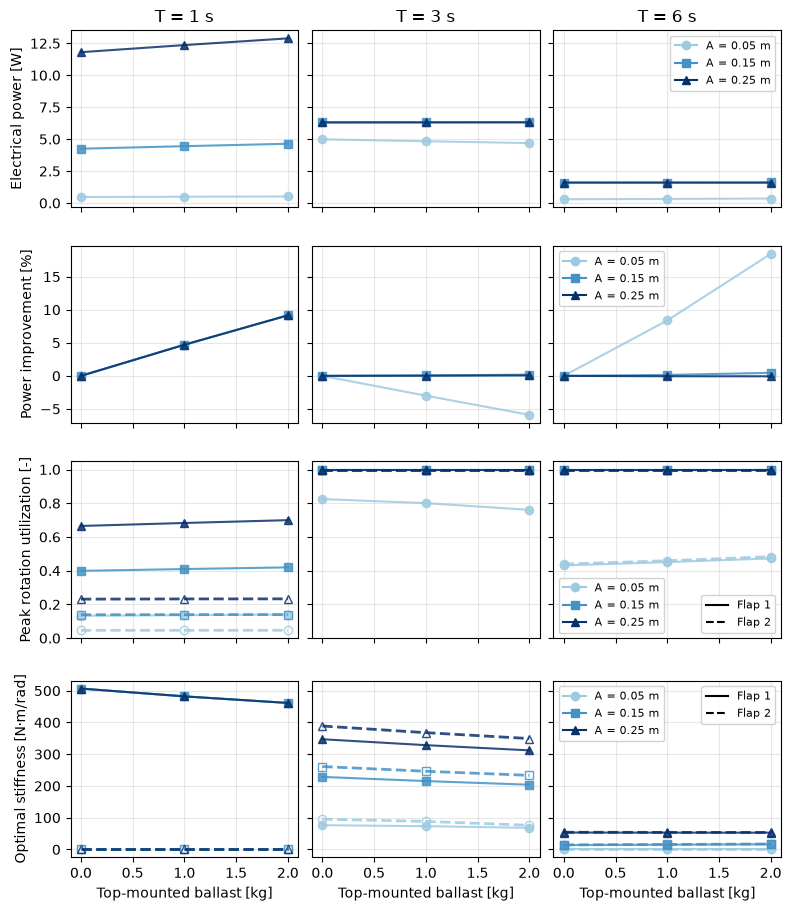

In [13]:
fig, axs = plt.subplots(
    4,
    len(wave_periods),
    sharex="col",
    sharey="row",
    figsize=(2.6 * len(wave_periods), 9),
    gridspec_kw={"hspace": 0.15},
    constrained_layout=True,
    squeeze=False,
)

colors = ["#9ecae1", "#4292c6", "#08306b"]
markers = ["o", "s", "^"]

for j, period in enumerate(wave_periods):
    for amplitude, color, marker in zip(wave_amplitudes, colors, markers):

        case_list = sorted(
            [
                c for c in case_outputs
                if np.isclose(c["wave_period"], period)
                and np.isclose(c["wave_amplitude"], amplitude)
            ],
            key=lambda c: c["top_mounted_ballast"],
        )

        if len(case_list) == 0:
            continue

        ballast = np.array([c["top_mounted_ballast"] for c in case_list])
        mean_elec_power = np.array([c["electrical_power"] for c in case_list])
        flap1_util = np.array([c["flap1_peak_rotation_utilization"] for c in case_list])
        flap2_util = np.array([c["flap2_peak_rotation_utilization"] for c in case_list])
        stiffness_flap1 = np.array([c["opt_stiffness_flap1"] for c in case_list])
        stiffness_flap2 = np.array([c["opt_stiffness_flap2"] for c in case_list])

        baseline_power = mean_elec_power[np.where(np.isclose(ballast, 0))[0][0]]
        power_improvement = 100 * (mean_elec_power - baseline_power) / baseline_power

        axs[0, j].plot(ballast, mean_elec_power, marker=marker, color=color, alpha=0.85)
        axs[1, j].plot(ballast, power_improvement, marker=marker, color=color, alpha=0.85)

        axs[2, j].plot(ballast, flap1_util, marker=marker, linestyle="-", color=color, alpha=0.85)
        axs[2, j].plot(ballast, flap2_util, marker=marker, linestyle="--", linewidth=2, color=color, markerfacecolor="none", alpha=0.85,)

        axs[3, j].plot(ballast, stiffness_flap1, marker=marker, linestyle="-", color=color, alpha=0.85)
        axs[3, j].plot(ballast,stiffness_flap2, marker=marker, linestyle="--", linewidth=2, color=color, markerfacecolor="none", alpha=0.85,)

    axs[0, j].set_title(f"T = {period:g} s")
    axs[3, j].set_xlabel("Top-mounted ballast [kg]")

for ax in axs.flatten():
    ax.grid(True, alpha=0.3)

axs[0, 0].set_ylabel("Electrical power [W]")
axs[1, 0].set_ylabel("Power improvement [%]")
axs[2, 0].set_ylabel("Peak rotation utilization [-]")
axs[3, 0].set_ylabel("Optimal stiffness [N·m/rad]")

amplitude_handles = [
    Line2D([0], [0], color=color, marker=marker, linestyle="-", label=f"A = {amp:.2f} m")
    for amp, color, marker in zip(wave_amplitudes, colors, markers)
]

axs[0, -1].legend(handles=amplitude_handles, fontsize=8, framealpha=0.9, loc="upper right")
axs[1, -1].legend(handles=amplitude_handles, fontsize=8, framealpha=0.9, loc="upper left")

flap_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="Flap 1"),
    Line2D([0], [0], color="k", linestyle="--", label="Flap 2"),
]

amp_legend = axs[2, -1].legend(handles=amplitude_handles, fontsize=8, framealpha=0.9, loc="lower left")
axs[2, -1].add_artist(amp_legend)
axs[2, -1].legend(handles=flap_handles, fontsize=8, framealpha=0.9, loc="lower right")

amp_legend = axs[3, -1].legend(handles=amplitude_handles, fontsize=8, framealpha=0.9, loc="upper left")
axs[3, -1].add_artist(amp_legend)
axs[3, -1].legend(handles=flap_handles, fontsize=8, framealpha=0.9, loc="upper right")